In [7]:
import numpy as np
import bilby
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from astropy.cosmology import Planck18, z_at_value
from nmma.core.conversion import luminosity_distance_to_redshift

events = pd.read_csv("./events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

posterior = np.load("./gw_posteriors/source_2/posterior.npz")
posterior_mm = np.load("./gw_posteriors/source_2/posterior_mm.npz")

In [12]:
def mass_source_frame_samples(prior, mm=False):
    samples = prior.sample(50_000)

    m1, m2 = bilby.gw.conversion.chirp_mass_and_mass_ratio_to_component_masses(samples["chirp_mass"], samples["mass_ratio"])
    if not mm:
        redshift = luminosity_distance_to_redshift(samples["luminosity_distance"])
    else:
        redshift = np.random.normal(loc=events.loc[2, "redshift"], scale=0.01 * events.loc[2, "redshift"], size=50_000)
    
    return m1  / (1+redshift), m2  / (1+redshift)


In [13]:
MCHIRP = events.loc[2, "chirp_mass"]
prior = bilby.gw.prior.PriorDict("./gw_posteriors/bns.prior")
prior["chirp_mass"] = bilby.gw.prior.UniformInComponentsChirpMass(MCHIRP-0.01, MCHIRP+0.01)

In [14]:
m1, m2 = mass_source_frame_samples(prior)
m1_mm, m2_mm = mass_source_frame_samples(prior, mm=True)

## GW only

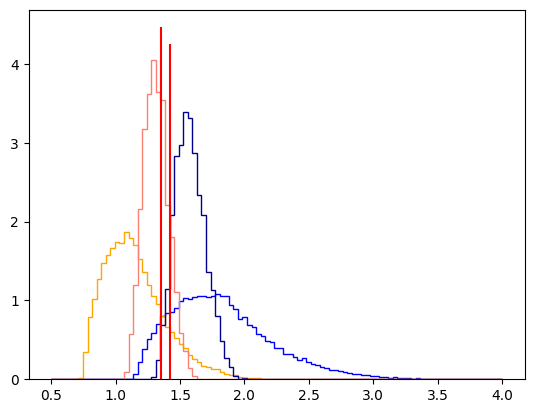

In [57]:
bins = np.linspace(0.5, 4, 100)

plt.hist(m1, density=True, histtype="step", color="blue", bins=bins)
plt.hist(m2, density=True, histtype="step", color="orange", bins=bins)

plt.hist(posterior["mass_1_source"], histtype="step", color="darkblue", bins=bins, density=True)
plt.hist(posterior["mass_2_source"], histtype="step", color="salmon", bins=bins, density=True)


plt.vlines([events.loc[2, "mass_1_source"]], *plt.gca().get_ylim(), color="red")
plt.vlines([events.loc[2, "mass_2_source"]], *plt.gca().get_ylim(), color="red")


## MM

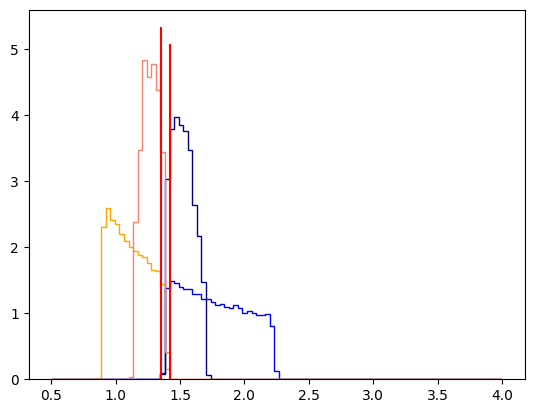

In [58]:
bins = np.linspace(0.5, 4, 100)

plt.hist(m1_mm, density=True, histtype="step", color="blue", bins=bins)
plt.hist(m2_mm, density=True, histtype="step", color="orange", bins=bins)

plt.hist(posterior_mm["mass_1_source"], histtype="step", color="darkblue", bins=bins, density=True)
plt.hist(posterior_mm["mass_2_source"], histtype="step", color="salmon", bins=bins, density=True)


plt.vlines([events.loc[2, "mass_1_source"]], *plt.gca().get_ylim(), color="red")
plt.vlines([events.loc[2, "mass_2_source"]], *plt.gca().get_ylim(), color="red")


## Uniform in Chirp and mass ratio

In [16]:
MCHIRP = events.loc[2, "chirp_mass"]
prior = bilby.gw.prior.PriorDict("./gw_posteriors/bns.prior")
prior["chirp_mass"] = bilby.gw.prior.Uniform(MCHIRP-0.01, MCHIRP+0.01)
prior["mass_ratio"] = bilby.gw.prior.Uniform(0.4, 1)

In [17]:
m1_uni, m2_uni = mass_source_frame_samples(prior)
m1_uni_mm, m2_uni_mm = mass_source_frame_samples(prior, mm=True)

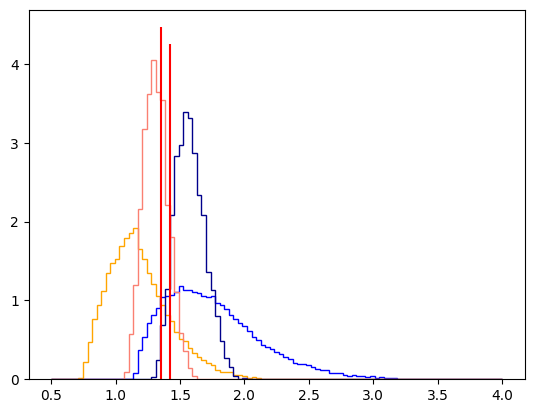

In [18]:
bins = np.linspace(0.5, 4, 100)

plt.hist(m1_uni, density=True, histtype="step", color="blue", bins=bins)
plt.hist(m2_uni, density=True, histtype="step", color="orange", bins=bins)

plt.hist(posterior["mass_1_source"], histtype="step", color="darkblue", bins=bins, density=True)
plt.hist(posterior["mass_2_source"], histtype="step", color="salmon", bins=bins, density=True)


plt.vlines([events.loc[2, "mass_1_source"]], *plt.gca().get_ylim(), color="red")
plt.vlines([events.loc[2, "mass_2_source"]], *plt.gca().get_ylim(), color="red")


plt.show()

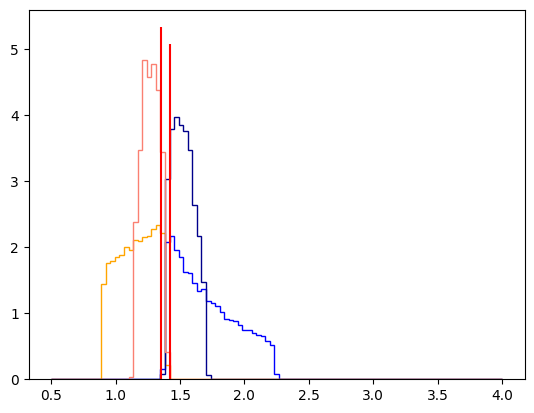

In [20]:
bins = np.linspace(0.5, 4, 100)

plt.hist(m1_uni_mm, density=True, histtype="step", color="blue", bins=bins)
plt.hist(m2_uni_mm, density=True, histtype="step", color="orange", bins=bins)

plt.hist(posterior_mm["mass_1_source"], histtype="step", color="darkblue", bins=bins, density=True)
plt.hist(posterior_mm["mass_2_source"], histtype="step", color="salmon", bins=bins, density=True)


plt.vlines([events.loc[2, "mass_1_source"]], *plt.gca().get_ylim(), color="red")
plt.vlines([events.loc[2, "mass_2_source"]], *plt.gca().get_ylim(), color="red")

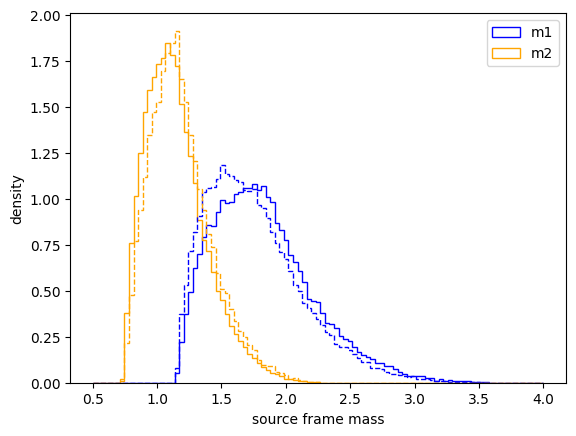

In [23]:
bins = np.linspace(0.5, 4, 100)

plt.hist(m1, density=True, histtype="step", color="blue", bins=bins)
plt.hist(m2, density=True, histtype="step", color="orange", bins=bins)

plt.hist(m1_uni, density=True, histtype="step", color="blue", bins=bins, linestyle="dashed")
plt.hist(m2_uni, density=True, histtype="step", color="orange", bins=bins, linestyle="dashed")

plt.xlabel("source frame mass")
plt.ylabel("density")
plt.legend(labels=["m1", "m2"])
plt.show()

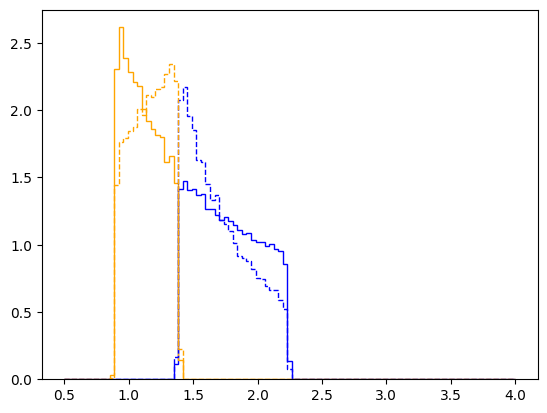

In [25]:
bins = np.linspace(0.5, 4, 100)

plt.hist(m1_mm, density=True, histtype="step", color="blue", bins=bins)
plt.hist(m2_mm, density=True, histtype="step", color="orange", bins=bins)

plt.hist(m1_uni_mm, density=True, histtype="step", color="blue", bins=bins, linestyle="dashed")
plt.hist(m2_uni_mm, density=True, histtype="step", color="orange", bins=bins, linestyle="dashed")

plt.show()